# 30-Day Readmission - Exploratory Data Analysis

**Dataset:** [Diabetes 130-US Hospitals, 1999–2008](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008) - *"Impact of HbA1c Measurement on
Hospital Readmission Rates"*, BioMed Research International.
 - 101,766 encounters of diabetic patients across 130 US hospitals.

**Question:** Hospitals face financial penalties for unplanned 30-day readmissions. Which patient, admission, and treatment factors predict them, and can we produce well-calibrated risk scores to prioritize discharge-planning resources?

**What this notebook does:** Cleans the raw encounter table, defines the binary target, and explores each feature group against readmission risk. It then validates that the production preprocessing pipeline (`src/readmission/preprocessing.py`) reproduces these decisions exactly, and closes with the metric choices used for modeling and a decision log summarizing every call made along the way.

**Contents**
1. Load & View Data
2. Missing Data 
3. Target Definition
4. Population Integrity (leakage & label problems)
5. Numeric features
6. Age
7. Admission / Discharge Context
8. Medical Specialty
9. Diagnosis codes (ICD-9 grouping)
10. Medications
11. Lab results
12. Feature Matrix
13. Metric Choice
14. Decision Log

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd() / "src"))

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="muted")

RAW = Path("..") / "data" / "raw" / "diabetic_data.csv"
df = pd.read_csv(RAW)
print(f"{df.shape[0]:,} encounters x {df.shape[1]} columns")

101,766 encounters x 50 columns


## 1. Load and View Data

In [2]:
df.head(5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df.dtypes

encounter_id                int64
patient_nbr                 int64
race                          str
gender                        str
age                           str
weight                        str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                    str
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride                   str
acetohexamide 

In [4]:
df.dtypes.value_counts()

str      37
int64    13
Name: count, dtype: int64

50 columns: two identifiers (`encounter_id`, `patient_nbr`), demographics, admission metadata (coded as integers we'll need to decode), utilization counts, three ICD-9 diagnosis fields, two lab results, 23 diabetes-medication columns, two medication change flags, and the label `readmitted`.

## 2. Missing Data

The dataset encodes missing values as the literal string `?` -> replace as Null.

In [5]:
missing_pct = (
    df.replace("?", np.nan).isna().mean().loc[lambda s: s > 0].sort_values(ascending=False)
)
missing_pct.to_frame("percent_missing").style.format("{:.1%}")

,percent_missing
weight,96.9%
max_glu_serum,94.7%
A1Cresult,83.3%
medical_specialty,49.1%
payer_code,39.6%
race,2.2%
diag_3,1.4%
diag_2,0.4%
diag_1,0.0%


**Decisions:**
| Column | Missing | Decision |
|---|---|---|
| `weight` | ~97% | **Drop.** Unusable due to the high proportion missing. |
| `medical_specialty` | ~49% | **Keep, with `missing` as its own category.** Informs us how a patient entered the hospital. |
| `payer_code` | ~40% | **Drops.** Insurance is highly predictive proxy variable. |
| `race` | ~2% | **Keep.** Label `missing` as its own category. |
| `diag_1..3` | <2% | **Keep.** Label `missing` as its own category after ICD grouping. |
| `A1Cresult`, `max_glu_serum` | ~83% / ~95% | "Missing" can mean the lab was never ordered. Keep as categoricals with an explicit "None" level |

## 3. Target Definition

`readmitted` has three values: `<30`, `>30`, and `No`.

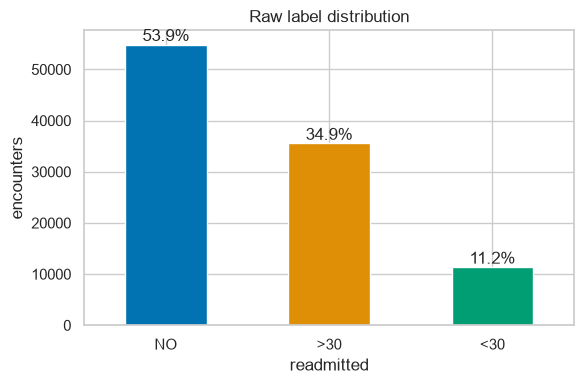

In [6]:
target_counts = df["readmitted"].value_counts()
ax = target_counts.plot.bar(figsize=(6, 4), rot=0, color=list(sns.color_palette("colorblind", 3)))
ax.set_title("Raw label distribution")
ax.set_ylabel("encounters")
for i, v in enumerate(target_counts):
    ax.text(i, v, f"{v / len(df):.1%}", ha="center", va="bottom")
plt.tight_layout()

Collapse to **binary: `<30`=1, everything else = 0**, because:
 - Early admission is classified as readmission within 30 days of discharge. 
 - Readmission passed 30 days usually indicates another issue rather than a discharge-planning failure.

## 4. Population Integrity (leakage & label problems)

**(a) Repeat patients.** Rows from the same patient are highly correlated. If a patient lands in both the train and test, the model is susceptible to memorizing patients.

In [7]:
enc_per_patient = df.groupby("patient_nbr").size()
print(f"unique patients: {len(enc_per_patient):,}")
print(f"patients with >1 encounter: {(enc_per_patient > 1).sum():,} "
      f"({(enc_per_patient > 1).mean():.1%})")
print(f"max encounters by a patient: {enc_per_patient.max():,}")

unique patients: 71,518
patients with >1 encounter: 16,773 (23.5%)
max encounters by a patient: 40


**Decision: Only keep the first encounter per patient** 

**(b) Patients who can't be readmitted.** The discharge column includes patients who have died or went to hospice. Including this label can influence how the model interprets and predicts readmission.

In [8]:
DEATH_HOSPICE = {11, 13, 14, 19, 20, 21}  # Codes for discharge dispositions that indicate death or hospice care
n_dead = df["discharge_disposition_id"].isin(DEATH_HOSPICE).sum()
print(f"encounters ending in death/hospice: {n_dead:,} ({n_dead / len(df):.1%})")
print(f"...of which readmitted <30: "
      f"{(df[df.discharge_disposition_id.isin(DEATH_HOSPICE)].readmitted == '<30').mean():.1%}")

encounters ending in death/hospice: 2,423 (2.4%)
...of which readmitted <30: 1.8%


In [9]:
# Distribution of gender
print(df["gender"].value_counts().to_string())

gender
Female             54708
Male               47055
Unknown/Invalid        3


In [10]:
# Apply all three filters (repeat patients, death/hospice, unknown gender)
clean = df.replace("?", np.nan)
clean = clean[~clean["discharge_disposition_id"].isin(DEATH_HOSPICE)]
clean = clean.sort_values("encounter_id").drop_duplicates("patient_nbr", keep="first")
clean = clean[clean["gender"] != "Unknown/Invalid"].reset_index(drop=True)
clean["target"] = (clean["readmitted"] == "<30").astype(int)

print(f"{len(df):,} raw encounters -> {len(clean):,} after cleaning")
print(f"30-day readmission rate after cleaning: {clean['target'].mean():.2%}")

101,766 raw encounters -> 69,987 after cleaning
30-day readmission rate after cleaning: 8.98%


Repeat encounters were disproportionately readmissions (~11% of encounters to ~9% of patients).

In [11]:
def rate_by(col, data=None, order=None):
    """30-day readmission rate per level of `col`, with counts."""
    data = clean if data is None else data
    grouped = data.groupby(col, observed=True)["target"].agg(["mean", "size"])
    return grouped.reindex(order) if order is not None else grouped.sort_values("mean")

## 5. Numeric Features

In [12]:
NUMERIC_RAW = [
    "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications", "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"
]
clean[NUMERIC_RAW].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,69987.0,4.27,2.93,1.0,2.0,3.0,6.0,14.0
num_lab_procedures,69987.0,42.88,19.89,1.0,31.0,44.0,57.0,132.0
num_procedures,69987.0,1.43,1.76,0.0,0.0,1.0,2.0,6.0
num_medications,69987.0,15.67,8.29,1.0,10.0,14.0,20.0,81.0
number_outpatient,69987.0,0.28,1.06,0.0,0.0,0.0,0.0,42.0
number_emergency,69987.0,0.10,0.51,0.0,0.0,0.0,0.0,42.0
number_inpatient,69987.0,0.18,0.60,0.0,0.0,0.0,0.0,12.0
number_diagnoses,69987.0,7.22,2.00,1.0,6.0,8.0,9.0,16.0


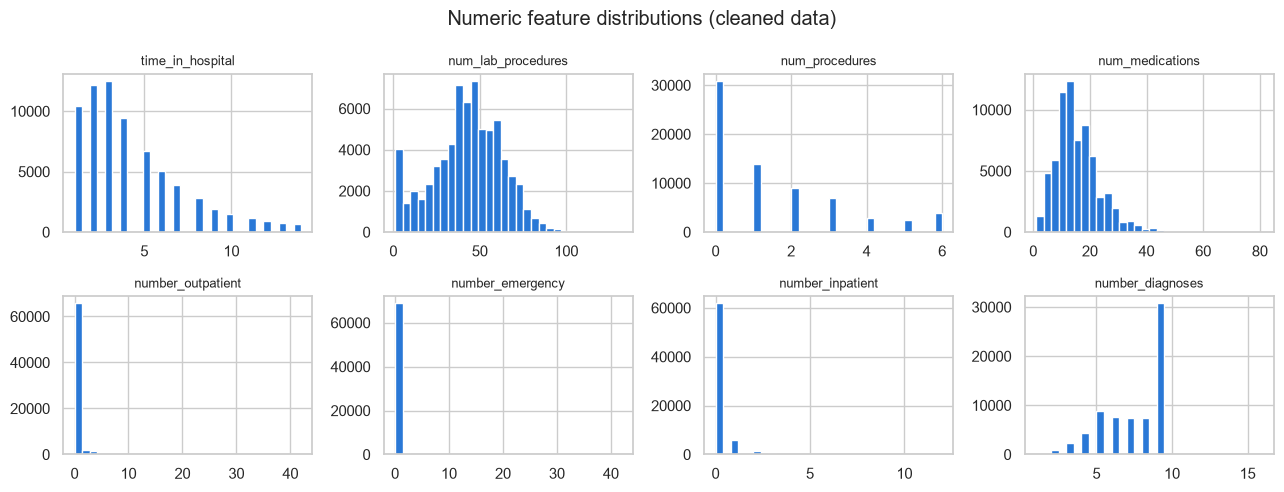

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5))
for ax, col in zip(axes.flat, NUMERIC_RAW):
    clean[col].hist(ax=ax, bins=30, color="#2A78D6")
    ax.set_title(col, fontsize=9)
fig.suptitle("Numeric feature distributions (cleaned data)")
plt.tight_layout()

Prior utilization (`number_outpatient`, `number_emergency`, and `number_inpatient`) are extremely right-skewed - most patients have 0.

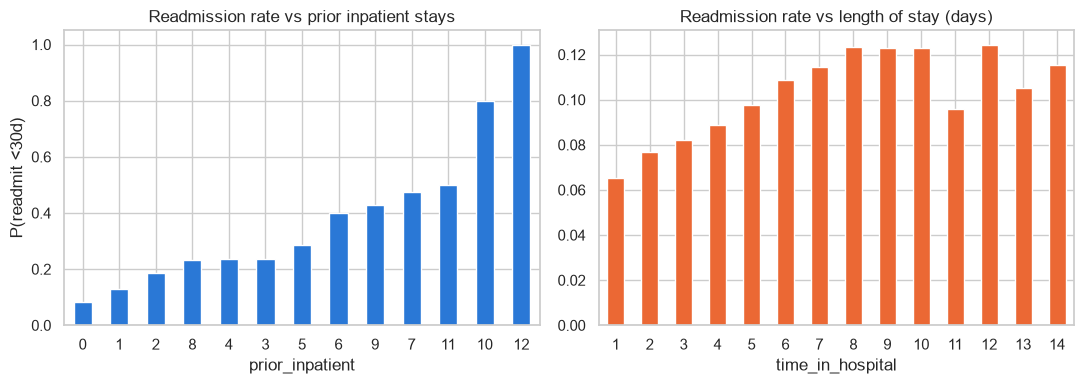

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
inp = clean.copy()
inp["prior_inpatient"] = inp["number_inpatient"]
rate_by("prior_inpatient", inp)["mean"].plot.bar(ax=axes[0], rot=0, color="#2A78D6")
axes[0].set_title("Readmission rate vs prior inpatient stays")
axes[0].set_ylabel("P(readmit <30d)")

rate_by("time_in_hospital")["mean"].sort_index().plot.bar(ax=axes[1], rot=0, color="#EB6834")
axes[1].set_title("Readmission rate vs length of stay (days)")
plt.tight_layout()

Prior inpatient stays show a high correlation with <30 day readmission. Length of stay trends upward more gently.

**Engineered feature:** `service_utilization` = outpatient + inpatient + emergency visits in the prior year, capturing a patient's overall level of healthcare utilization.

## 6. Age

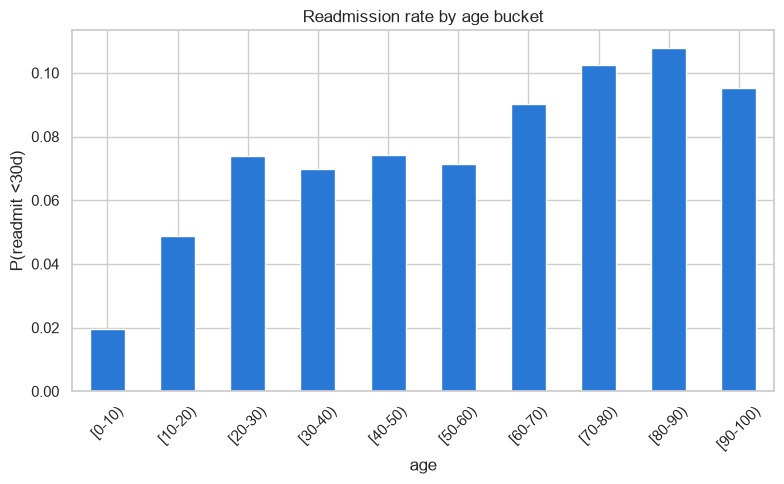

In [15]:
age_order = sorted(clean["age"].unique())
ax = rate_by("age", order=age_order)["mean"].plot.bar(figsize=(8, 5), rot=45, color="#2A78D6")
ax.set_title("Readmission rate by age bucket")
ax.set_ylabel("P(readmit <30d)")
plt.tight_layout()

Risk and age show a positive relationship. To preserve ordering we will **map each bucket to its numeric midpoint.**

## 7. Admission / Discharge Context

`admission_type_id`, `discharge_disposition_id`, `admission_source_id` are integer codes with levels 8/30/26, respectively. Code mappings are shown in `IDS_mapping.csv`.
Many of these levels are rare or redundant features.

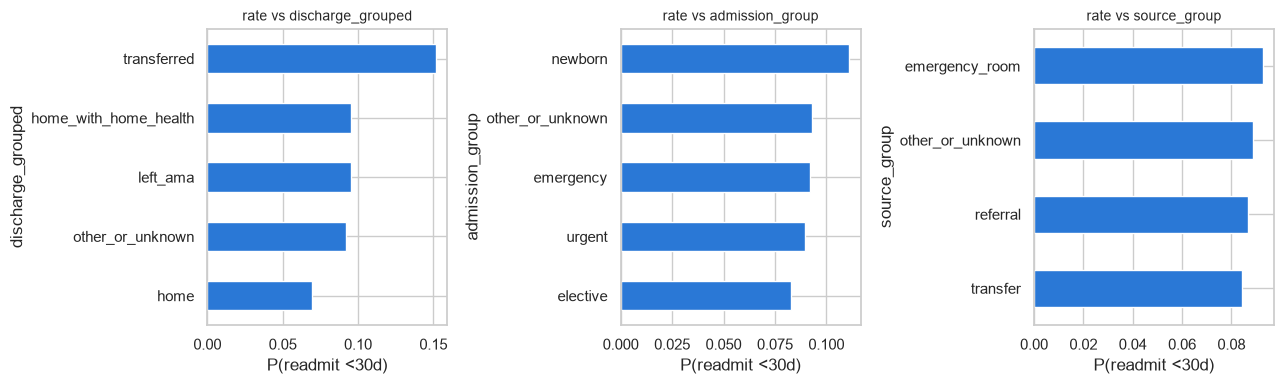

In [16]:
from readmission.preprocessing import (
    group_admission_source,
    group_admission_type,
    group_discharge_disposition,
    group_medical_specialty,
    map_icd9_to_category,
)

clean["discharge_grouped"] = clean["discharge_disposition_id"].apply(group_discharge_disposition)
clean["admission_group"] = clean["admission_type_id"].apply(group_admission_type)
clean["source_group"] = clean["admission_source_id"].apply(group_admission_source)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["discharge_grouped", "admission_group", "source_group"]):
    stats = rate_by(col)
    stats["mean"].plot.barh(ax=ax, color="#2A78D6")
    ax.set_title(f"rate vs {col}", fontsize=10)
    ax.set_xlabel("P(readmit <30d)")
plt.tight_layout()

Discharge destination indicates that patients discharged to **home with health** or **transferred** show meaningfully higher raisk that plain discharge home. We will keep discharge disposition as a first-class grouped feature.

## 8. Medical Specialty

In [17]:
print(f"distinct specialties: {clean['medical_specialty'].nunique()}")
clean["medical_specialty"].value_counts()

distinct specialties: 70


medical_specialty
InternalMedicine          10641
Family/GeneralPractice     4978
Emergency/Trauma           4393
Cardiology                 4207
Surgery-General            2205
                          ...  
SportsMedicine                1
Speech                        1
Perinatology                  1
Neurophysiology               1
Resident                      1
Name: count, Length: 70, dtype: int64

In [18]:
clean["specialty_group"] = clean["medical_specialty"].apply(group_medical_specialty)
rate_by("specialty_group").style.format({"mean": "{:.2%}"})

,mean,size
specialty_group,,
cardiology,7.20%,4207
emergency_trauma,7.83%,4393
surgery,7.92%,3751
other,8.45%,8365
missing,9.24%,33652
family_general_practice,9.74%,4978
internal_medicine,9.76%,10641


~70 raw levels, half missing - there is high cardinality with informative missingness. Group into 6 levels: the four largest specialties (`InternalMedicine`, `Family/GeneralPractice`, `Emergency/Trauma`, `Cardiology`), `surgery` (all surgical subspecialties combined), `other` (everything else), and `missing` as its own level. A missing specialty likely reflects an unplanned/ED admission where no specialty was ever recorded, not random data loss, so it's informative rather than noise.

## 9. Diagnosis Codes (ICD-9 chapter grouping)

In [19]:
print(f"Distinct primary diagnoses (diag_1): {clean['diag_1'].nunique()}")

Distinct primary diagnoses (diag_1): 694


`diag_1` alone has 694 distinct ICD-9 codes - too sparse to use directly. Collapse `diag_1`, `diag_2`, and `diag_3` to their **ICD-9 chapter** (e.g. Circulatory, Respiratory, Diabetes), using the grouping from Strack et al. (2014), to reduce cardinality while preserving clinically meaningful categories.

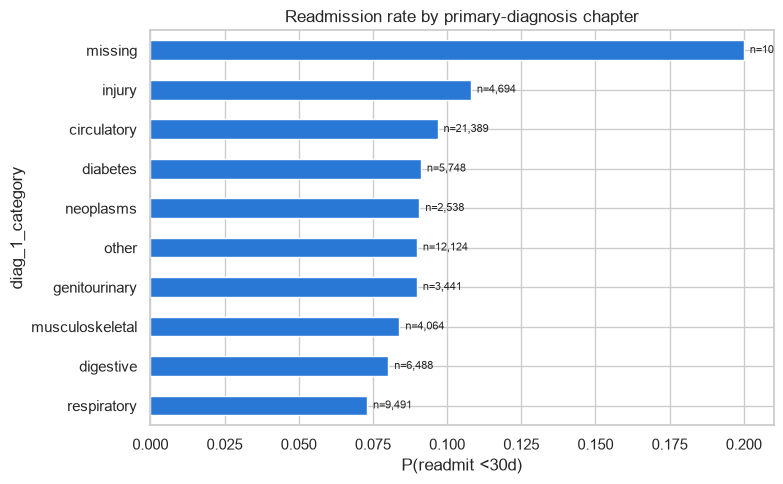

In [20]:
clean["diag_1_category"] = clean["diag_1"].map(map_icd9_to_category)
stats = rate_by("diag_1_category")
fig, ax = plt.subplots(figsize=(8, 5))
stats["mean"].plot.barh(ax=ax, color="#2A78D6")
ax.set_title("Readmission rate by primary-diagnosis chapter")
ax.set_xlabel("P(readmit <30d)")
for i, (rate, size) in enumerate(zip(stats["mean"], stats["size"])):
    ax.text(rate, i, f"  n={size:,}", va="center", fontsize=8)
plt.tight_layout()

Circulatory disease dominates diagnosis volume (~30% of encounters), but readmission risk is highest for injury as a primary diagnosis (10.8%), while diabetes itself sits near the cohort average (~9%).

## 10. Medications

23 columns, one per drug, each indicating whether that drug was prescribed and, if so, whether its dosage changed (`No` / `Steady` / `Up` / `Down`).

In [21]:
MED_COLS = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride", "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton", "insulin", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone",
]
non_no = (clean[MED_COLS] != "No").sum().sort_values(ascending=False)
non_no.to_frame("encounters_not_'No'")

,encounters_not_'No'
insulin,35722
metformin,14904
glipizide,9009
glyburide,7776
pioglitazone,5265
rosiglitazone,4660
glimepiride,3698
repaglinide,917
glyburide-metformin,496
nateglinide,491


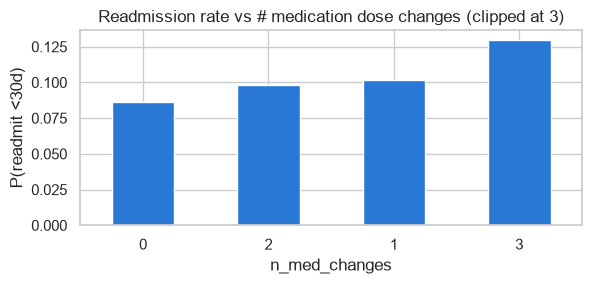

In [22]:
clean["n_med_changes"] = clean[MED_COLS].isin(["Up", "Down"]).sum(axis=1)
ax = rate_by(clean["n_med_changes"].clip(upper=3))["mean"].plot.bar(
    figsize=(6, 3), rot=0, color="#2A78D6"
)
ax.set_title("Readmission rate vs # medication dose changes (clipped at 3)")
ax.set_ylabel("P(readmit <30d)")
plt.tight_layout()

Of the 23 diabetes-medication columns, only `insulin` (~51% of encounters) and `metformin` (~21%) see meaningful use. The remaining 21 are prescribed in under 15% of encounters each, and three (`examide`, `citoglipton`, `glimepiride-pioglitazone`) never appear at all.

**Decision:** Keep `insulin` and `metformin` as individual categorical features, and collapse the remaining 21 columns into two engineered counts:
- `n_medication_changes`: number of drugs whose dose changed (`Up`/`Down`) this encounter, a proxy for how unstable the regimen was at discharge.
- `n_active_medications`: number of diabetes drugs the patient is on, a proxy for overall regimen complexity.

## 11. Lab Results

`A1Cresult` and `max_glu_serum` are only populated when the corresponding test was ordered. A missing value means not tested, not unknown. We check how often each test was actually ordered before deciding how to encode them.

                   A1Cresult  max_glu_serum
fraction measured      0.184          0.048


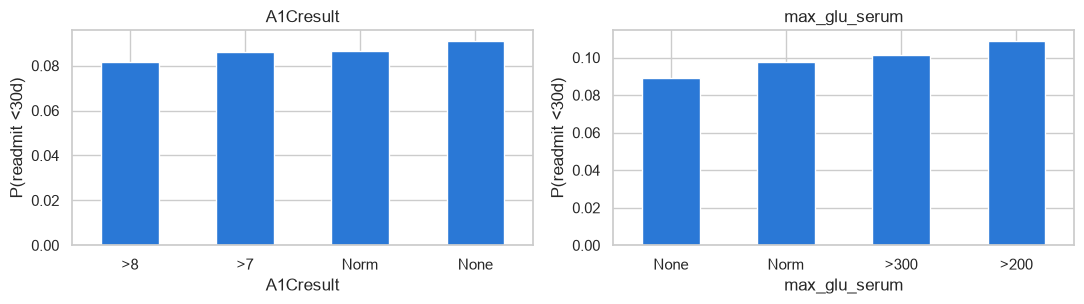

In [23]:
labs = clean[["A1Cresult", "max_glu_serum", "target"]].fillna("None")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, col in zip(axes, ["A1Cresult", "max_glu_serum"]):
    stats = rate_by(col, data=labs)
    stats["mean"].plot.bar(ax=ax, rot=0, color="#2A78D6")
    ax.set_title(col)
    ax.set_ylabel("P(readmit <30d)")
plt.tight_layout()

summary = pd.Series(
    {
        "A1Cresult": (labs["A1Cresult"] != "None").mean(),
        "max_glu_serum": (labs["max_glu_serum"] != "None").mean(),
    },
    name="fraction measured",
)
print(summary.to_frame().T.round(3).to_string())

**Decision:** Only ~18% of encounters have an HbA1c result and ~5% have a glucose serum result - consistent with these tests being ordered selectively rather than missing at random. Keep both as categoricals with an explicit None level (rather than dropping or imputing), since whether a test was ordered is itself informative.

## 12. Feature Matrix

Everything above is implemented in `src/readmission/preprocessing.py`. The cell below runs the real pipeline and asserts it reproduces this notebook's row count and target rate.

In [24]:
from readmission.preprocessing import (
    clean_encounters,
    engineer_features,
    make_binary_target,
)

cleaned_src = clean_encounters(df)
X = engineer_features(cleaned_src)
y = make_binary_target(cleaned_src["readmitted"])

# Pipeline checks to ensure that the feature matrix and target vector are consistent with the cleaned data
assert len(cleaned_src) == len(clean), "Feature columns mismatch"
assert abs(y.mean() - clean["target"].mean()) < 1e-12, "Target mismatch"
print(f"feature matrix: {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"positive rate: {y.mean():.2%}")
X.head(3)

feature matrix: 69,987 rows x 27 features
positive rate: 8.98%


,age_midpoint,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,service_utilization,n_medication_changes,n_active_medications,race,gender,admission_type,discharge_disposition,admission_source,medical_specialty_group,diag_1_category,diag_2_category,diag_3_category,max_glu_serum,A1Cresult,insulin,metformin,change,diabetesMed
0,85,13,68,2,28,0,0,0,8,0,0,2,Caucasian,Female,urgent,home,transfer,missing,circulatory,circulatory,other,None,None,Steady,No,Ch,Yes
1,95,12,33,3,18,0,0,0,8,0,0,2,Caucasian,Female,elective,transferred,transfer,internal_medicine,circulatory,neoplasms,respiratory,None,None,Steady,No,Ch,Yes
2,45,1,51,0,8,0,0,0,5,0,0,2,Caucasian,Male,emergency,home,emergency_room,missing,neoplasms,neoplasms,diabetes,None,None,Steady,No,Ch,Yes


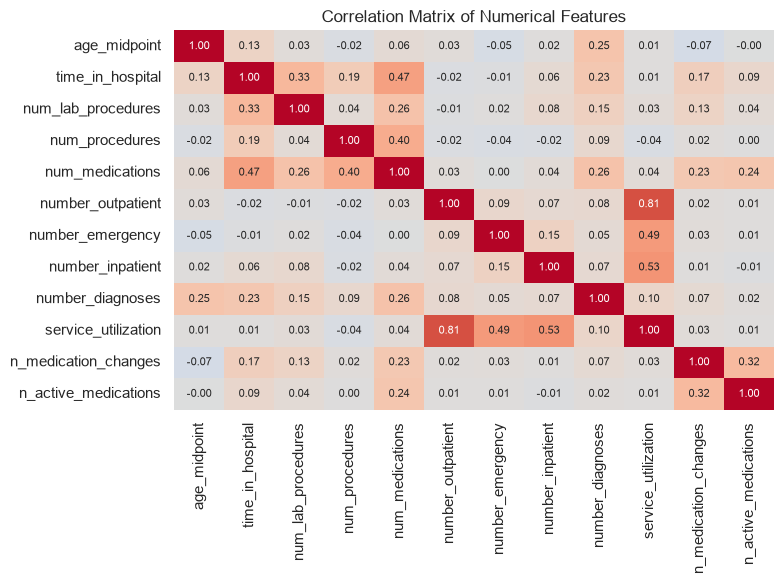

In [25]:
numeric_cols = X.select_dtypes(include="number").columns
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(X[numeric_cols].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f", 
            annot_kws={"size": 8}, cbar=False, ax=ax)
ax.set_title("Correlation Matrix of Numerical Features")
plt.tight_layout()

Correlations are modest overall. `service_utilization` correlates strongly with its three components (r = 0.49–0.81) by construction, as expected. `n_active_medications` and `num_medications` are only weakly related (r = 0.24), despite the overlap, they capture different things (all administered meds vs. diabetes-med dose activity), so both are worth keeping. No feature pair outside the constructed one exceeds r ≈ 0.47, so there's no sign of a multicollinearity.

## 13. Metric Choice

In [26]:
from readmission.evaluation import no_skill_baselines

floors = no_skill_baselines(y)
print(f"prevalence = {floors['prevalence']:.4%}\n")
for metric, value in floors.items():
    if metric != "prevalence":
        print(f"  no-skill {metric:<10} {value:.4%}")

prevalence = 8.9802%

  no-skill accuracy   91.0198%
  no-skill roc_auc    50.0000%
  no-skill pr_auc     8.9802%
  no-skill brier      8.1738%
  no-skill log_loss   30.2080%




With a ~9% positive rate:
 - **Accuracy - rejected:** always predicting "not readmitted" scores 91.02%. High but meaningless - it just reflects the class umbalance.
 - **ROC-AUC - primary ranking metric:** threshold-free and prevalence independent, so it's comparable across cohorts and over time..
 - **PR-AUC - reported alongside:** ROC-AUC can look optimistic under imbalance since it's diluted by the large true-negative pool. PR-AUC focuses on the positive class directly, which matters when only ~9% of encounters are readmissions.
 - **Lift at Top-k:**  operational metric - measures how effectively the model concentrates risk in the top-ranked patients, which is what determines how efficiently a care management team can target interventions.
 - **Brier score:** a score that captures both discrimination and calibration - a useful summary cehck, but not diagnostic on its own.
 - **ECE + reliability diagram:** the target calibration check. Tells us if predicting 20% actually means ~20% observed, which Brier alone can't isolate.

## 14. Decision Log

| # | Decision  | Reason |
|---|---|---|
| 1 | Binary target: `readmitted == "<30"` | Readmission within 30 days is classified as unplanned. Readmission after 30 days can indicate a new issue. |
| 2 | Drop `weight`, `payer_code` | 97% missing. Billing proxy chosen not to use |
| 3 | Drop death/hospice discharges | Cannot be readmitted - label leakage otherwise |
| 4 | First encounter per patient only | Indepence of rows for honest CV |
| 5 | Age buckets -> numeric midpoints | Preserves ordering |
| 6 | Group admission/discharge/source ID's | 8/30/26 raw levels -> 4-6 meaningful ones |
| 7 | Group `medical_specialty`, keep `missing` | ~70 levels, 49% missing but informative |
| 8 | ICD-9 → 9 disease chapters (`diag_1..3`) | ~700 codes -> estimable groups |
| 9 | Medications -> `insulin`, `metformin` + 2 counts | 23 sparse columns -> dense signals |
| 10 | Labs: keep `None` as a category | "Not measured" is informative |
| 11 | `service_utilization` engineered | Overall level of prior utilization is the dominant predictor |
| 12 | Class weights, not resampling | Keeps probabilities calibratable |
| 13 | Metrics: ROC-AUC + PR-AUC + lift + Brier + ECE | Ranking (ROC-AUC), rare-class precision (PR-AUC), operational targeting (Lift), overall probability accuracy (Brier), and calibration specifically (ECE) |